## Load things

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

## Intro stuff

In [4]:
f_values = [1, 0.3, 0.1, 0.01]

In [5]:
dust_sum_of_sq

<function DustModelFunctions.dust_sum_of_sq(sf, model_Pw, obs_POLF)>

In [6]:
# Constants
bands = ['Band 4 nterms2', 'Band 5', 'Band 6', 'Band 7 nterms2']
bands_naming = ['Band4_nterms2', 'Band5', 'Band6', 'Band7_nterms2']
bands_labels = ['Band 4', 'Band 5', 'Band 6', 'Band 7']

num_bands = len(bands)

lambda_bands_cm = mm_to_cm([lambda_mm[b] for b in bands])
band_colors = [alma_band_colors[b] for b in bands]

In [7]:
load_POLF

<function POLF_Functions.load_POLF(bands)>

In [8]:
df_POLF = load_POLF(bands)

In [9]:
df_POLF

,Band,POLF_Gaussian,POLF_maxPOLI,POLF_maxStokesI,POLF_mean
0,Band 4 nterms2,1.187728,1.561384,1.367706,1.372273
1,Band 5,0.914925,1.030456,0.972170,0.972517
2,Band 6,1.445312,1.486287,1.463922,1.465174
3,Band 7 nterms2,0.830213,1.084152,1.042140,0.985502


In [10]:
# CSV filenames keyed by f value
csv_files = {
    1:   "P_omega_vs_amax_f_1_Zhang3Bounds.csv",
    0.3: "P_omega_vs_amax_f_0_3_Zhang3Bounds.csv",
    0.1: "P_omega_vs_amax_f_0_1_Zhang3Bounds.csv",
    0.01:"P_omega_vs_amax_f_0_01_Zhang3Bounds.csv"
}

# Bands you’re using
# bands = [4, 5, 6, 7]

# Storage
a_max_f_dist_micron = []    # (4, N)
P_times_omega_all = []      # (4, N, 4)

# Loop through each CSV
for f, fname in csv_files.items():
    df = pd.read_csv(P_omega_data_folder_path + fname)
    
    # x-axis (grain sizes in micron)
    a_max_f_dist_micron.append(df["a_max_f_micron"].values)
    
    # y-values (P*omega for each band)
    P_times_omega = np.column_stack([df[f"P_times_omega_{b_name}"].values for b_name in bands_naming])
    P_times_omega_all.append(P_times_omega)

# Convert to numpy arrays
a_max_f_dist_micron = np.array(a_max_f_dist_micron)   # shape (4, N)
P_times_omega_all = np.array(P_times_omega_all)       # shape (4, N, 4)

print("a_max_f_dist_micron:", a_max_f_dist_micron.shape)
print("P_times_omega_all:", P_times_omega_all.shape)

a_max_f_dist_micron: (4, 400)
P_times_omega_all: (4, 400, 4)


## Plotting

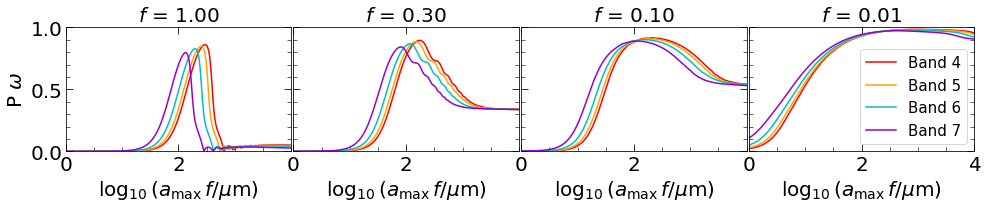

In [12]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(1, 4, figsize=(14, 3))



for i in range(4): # 4 i values since 4 f values 
    if i == 0:
        ax[i].set_ylabel('P $\omega$', fontsize=axis_label_fs)
    else:
        ax[i].set_yticklabels([])    # remove y tick labels
        ax[i].set_ylabel('')         # remove y axis label if any
        ax[i].tick_params(left=False)  # optionally remove left ticks
        
    
    # Add axis labels
    ax[i].set_xlabel(r'$\log_{10}(a_{\mathrm{max}}\, f / \mu\mathrm{m})$', fontsize=axis_label_fs)

    
    ax[i].minorticks_on()

    ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)

    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True,   length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True,   right=True, length=7, labelsize=axis_num_fs)


    ax[i].set_title(f'$f$ = {f_values[i]:.2f}', fontsize = 20)


    for j in range(num_bands):
        ax[i].plot(np.log10(a_max_f_dist_micron[i] * f_values[i]),
                P_times_omega_all[i, :, j],
                color = band_colors[j],
                ls = '-',
                label = f'{bands_labels[j]}')
        
#         ax[i].axhline(df_POLF['POLF_mean'][j], color = band_colors[j], ls = '--', lw = 3)
        
    ax[i].set_xlim(0, 4)
    ax[i].set_ylim(0, 1)
    




# # Remove scientific notation from x-axis
# ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
# ax.ticklabel_format(style='plain', axis='x')

# # ---------------------------------------------------------------------------------
# ax.legend(fontsize = legend_text_fs)
# # ---------------------------------------------------------------------------------
 
    


for i in range(4):  # 4 subplots
    if i < 3:  # all but the last panel
        ticks = ax[i].get_xticks()
        labels = [lab.get_text() for lab in ax[i].get_xticklabels()]
        # Remove the last label (the "4")
        ax[i].set_xticks(ticks[:-1])
        ax[i].set_xticklabels(labels[:-1])

# Add a legend to the most right plot
ax[3].legend(fontsize = legend_text_fs)
        
        
plt.tight_layout()
plt.subplots_adjust(wspace = 0.01, hspace=0)


plt.savefig(slideshow_image_folder_path + '/DustModels/'+ "Pw_vs_grainsize_porosity.png", 
            dpi=300, 
            facecolor='white',
            bbox_inches='tight')  